# 1. Autoencoders

Let's train an autoencoder network to 'denoise' pictures e.g. learn a network to take out the noise form a picture to create a nicer picture without any noise. This trained model can then be used to 'denoise' images that it hasn't seen before and convert them to cleaner images.

In [ ]:
# import libraries
import tensorflow as tf
print("Tensorflow version: ", tf.__version__)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

Tensorflow version:  2.17.1


In [ ]:
# load the MNIST digit dataset into train and test set
from tensorflow.keras.datasets import mnist

(X_train, y_train),(X_test, y_test) = mnist.load_data()

In [ ]:
# show the shape of the data
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (60000, 28, 28)
y_train shape:  (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)


Index :  53587
Label of the image :  1


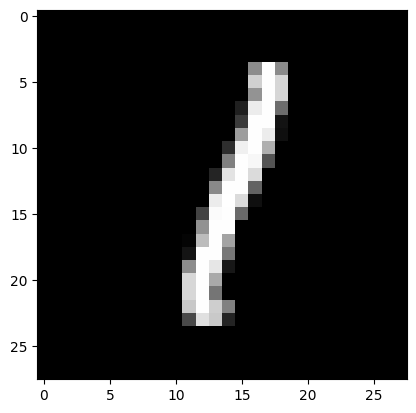

In [ ]:
# Let's view some images! Re-run this cell to look at examples of digits
i = random.randint(1,60000) # select any random index from 1 to 60,000

plt.imshow( X_train[i] , cmap = 'gray') # reshape and plot the image

print("Index : ", i)
print("Label of the image : ", y_train[i])

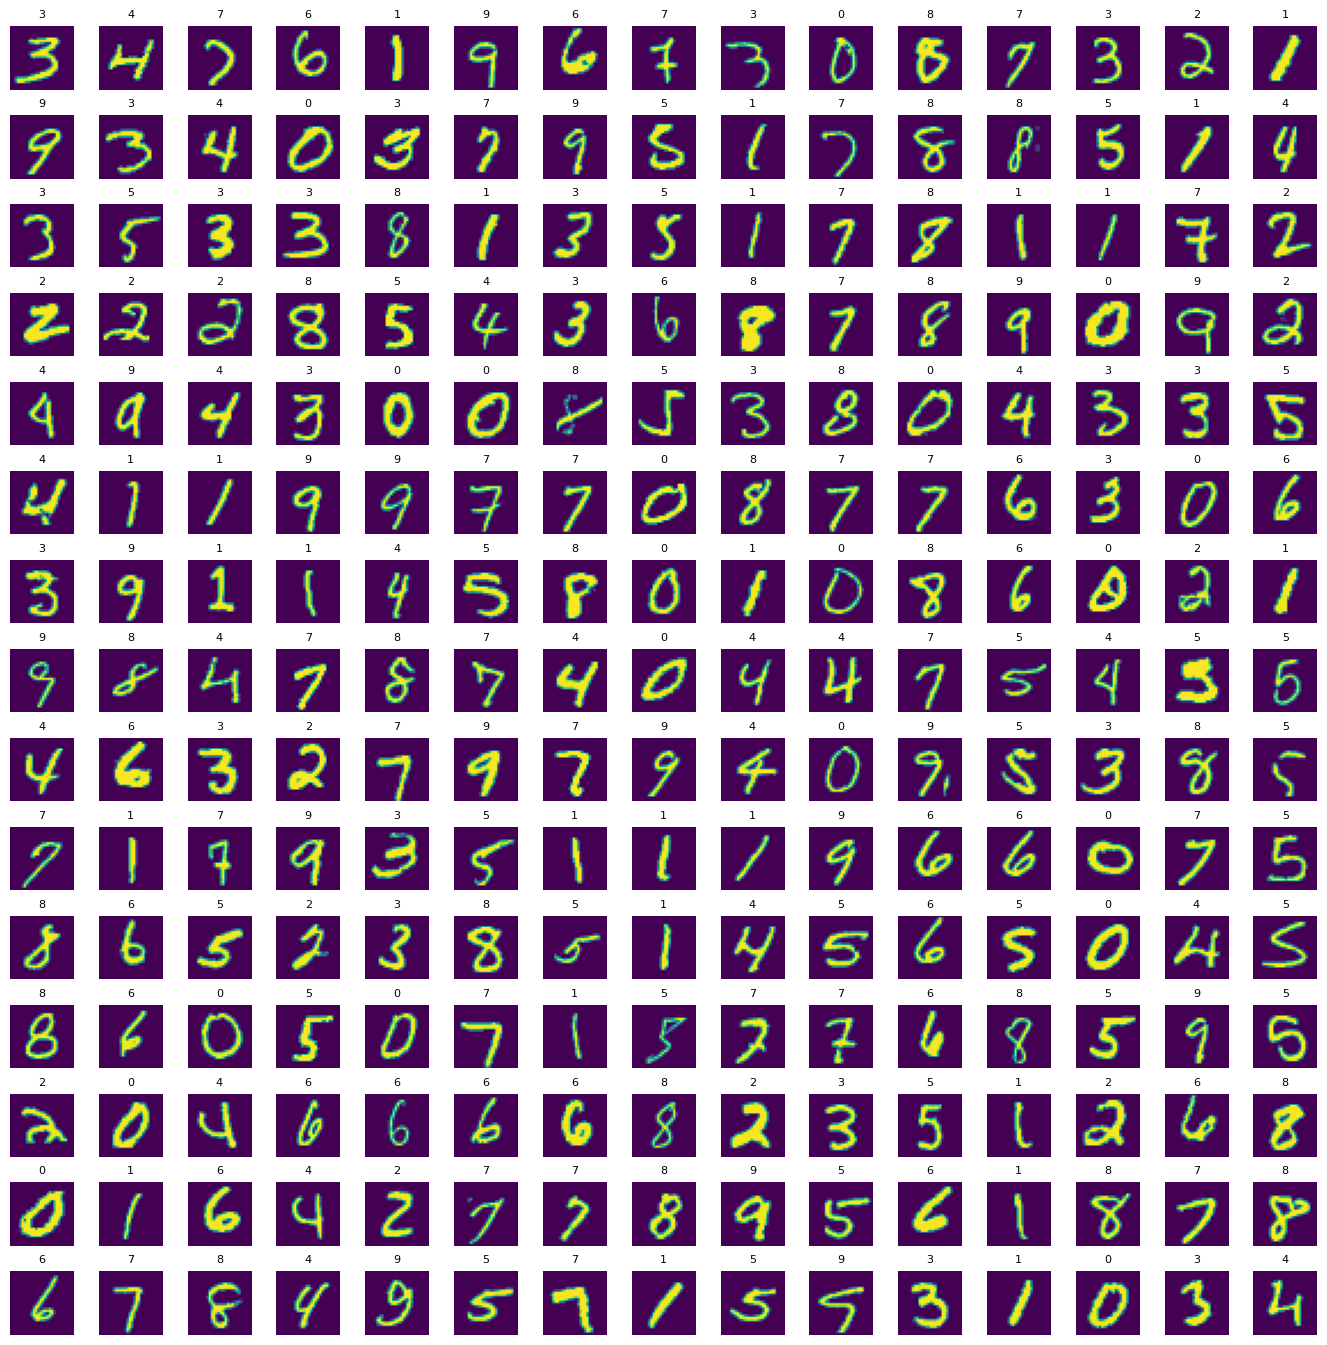

In [ ]:
# Let's view more images in a grid format
# Define the dimensions of the plot grid
W_grid = 15
L_grid = 15

# fig, axes = plt.subplots(L_grid, W_grid)
# subplot return the figure object and axes object
# we can use the axes object to plot specific figures at various locations

fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))

axes = axes.ravel() # flaten the 15 x 15 matrix into 225 array

n_training = len(X_train) # get the length of the training dataset

for i in np.arange(0, W_grid * L_grid): # create evenly spaces variables

    # Select a random number
    index = np.random.randint(0, n_training)
    # read and display an image with the selected index
    axes[i].imshow( X_train[index] )
    axes[i].set_title(y_train[index], fontsize = 8)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)

In [ ]:
# Let's normalize the data
X_train = X_train / 255
X_test = X_test / 255

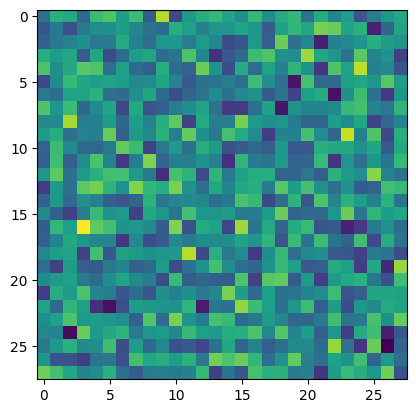

In [ ]:
# Let's create some noise with the same dimensions as the original image (28,28)
noise_factor = 0.2
added_noise = noise_factor * np.random.randn(*(28,28))
plt.imshow(added_noise)

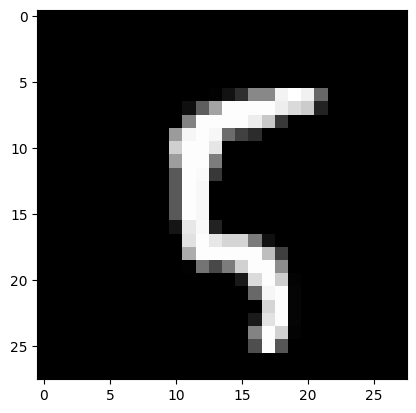

In [ ]:
# Let's take a sample image and add noise to it
noise_factor = 0.2 #value between 0 (no noise) to 1 (max noise)

added_noise = noise_factor * np.random.randn(*(28,28))
sample_image = X_train[100]
noisy_sample_image = sample_image + added_noise

#clip the pixel values between 0 and 1
noisy_sample_image = np.clip(noisy_sample_image, 0., 1.)

plt.imshow(sample_image, cmap="gray")

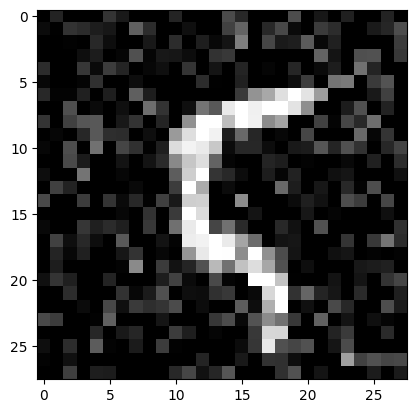

In [ ]:
plt.imshow(noisy_sample_image, cmap="gray")

In [ ]:
# Let's do the same operation over all the images contained in the training dataset
X_train_noisy = []
noise_factor = 0.4

for sample_image in X_train:
  sample_image_noisy = sample_image + noise_factor * np.random.randn(*(28,28))
  sample_image_noisy = np.clip(sample_image_noisy, 0., 1.)
  X_train_noisy.append(sample_image_noisy)

# Convert from list to array
X_train_noisy = np.array(X_train_noisy)

In [ ]:
# Let's do the same operation for the testing dataset as well
X_test_noisy = []
noise_factor = 0.4

for sample_image in X_test:
  sample_image_noisy = sample_image + noise_factor * np.random.randn(*(28,28))
  sample_image_noisy = np.clip(sample_image_noisy, 0., 1.)
  X_test_noisy.append(sample_image_noisy)

# Convert from list to array
X_test_noisy = np.array(X_test_noisy)

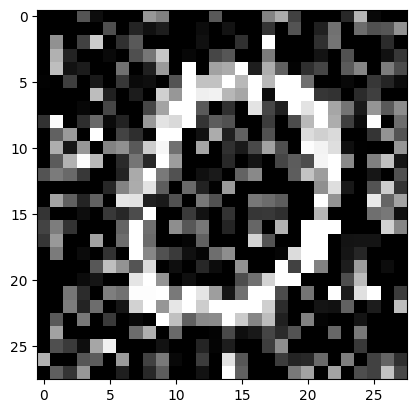

In [ ]:
# Let's make sure that the test images are noisy as well!
plt.imshow(X_test_noisy[10], cmap = 'gray')

In [ ]:
# Specify the autoencoder deep learning model

autoencoder = tf.keras.models.Sequential()

# Let's build the encoder CNN
autoencoder.add(tf.keras.layers.Input(shape=[28, 28, 1]))
autoencoder.add(tf.keras.layers.Conv2D(16, (3,3), strides=1, padding="same"))
autoencoder.add(tf.keras.layers.MaxPooling2D((2,2), padding="same"))

autoencoder.add(tf.keras.layers.Conv2D(8, (3,3), strides=1, padding="same"))
autoencoder.add(tf.keras.layers.MaxPooling2D((2,2), padding="same"))

# Encoded image (code layer)
autoencoder.add(tf.keras.layers.Conv2D(8, (3,3), strides=1, padding="same"))

# Let's build the decoder CNN
autoencoder.add(tf.keras.layers.UpSampling2D((2, 2)))
autoencoder.add(tf.keras.layers.Conv2DTranspose(8,(3,3), strides=1, padding="same"))

autoencoder.add(tf.keras.layers.UpSampling2D((2, 2)))
# autoencoder.add(tf.keras.layers.Conv2DTranspose(1, (3,3), strides=1, padding="same"))
autoencoder.add(tf.keras.layers.Conv2DTranspose(1, (3,3), strides=1, activation='sigmoid', padding="same"))

In [ ]:
# Build the autoencoder
autoencoder.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 28, 28, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 14, 14, 8)           │           1,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 7, 7, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 7, 7, 8)             │             584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_10 (UpSampling2D)      │ (None, 14, 14, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_10                  │ (None, 14, 14, 8)           │             584 │
│ (Conv2DTranspose)                    │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_11 (UpSampling2D)      │ (None, 28, 28, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_11                  │ (None, 28, 28, 1)           │              73 │
│ (Conv2DTranspose)                    │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the autoencoder
autoencoder.fit(X_train_noisy.reshape(-1, 28, 28, 1),
          X_train.reshape(-1, 28, 28, 1),
          epochs=10,
          batch_size=200)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3112
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1314
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1213
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1167
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1139
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1120
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1105
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1096
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1086
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1083


In [ ]:
# Let's pick up 15 images and run them through the trained autoencoder
denoised_images = autoencoder.predict(X_test_noisy[:15].reshape(-1, 28, 28, 1))
denoised_images.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


(15, 28, 28, 1)

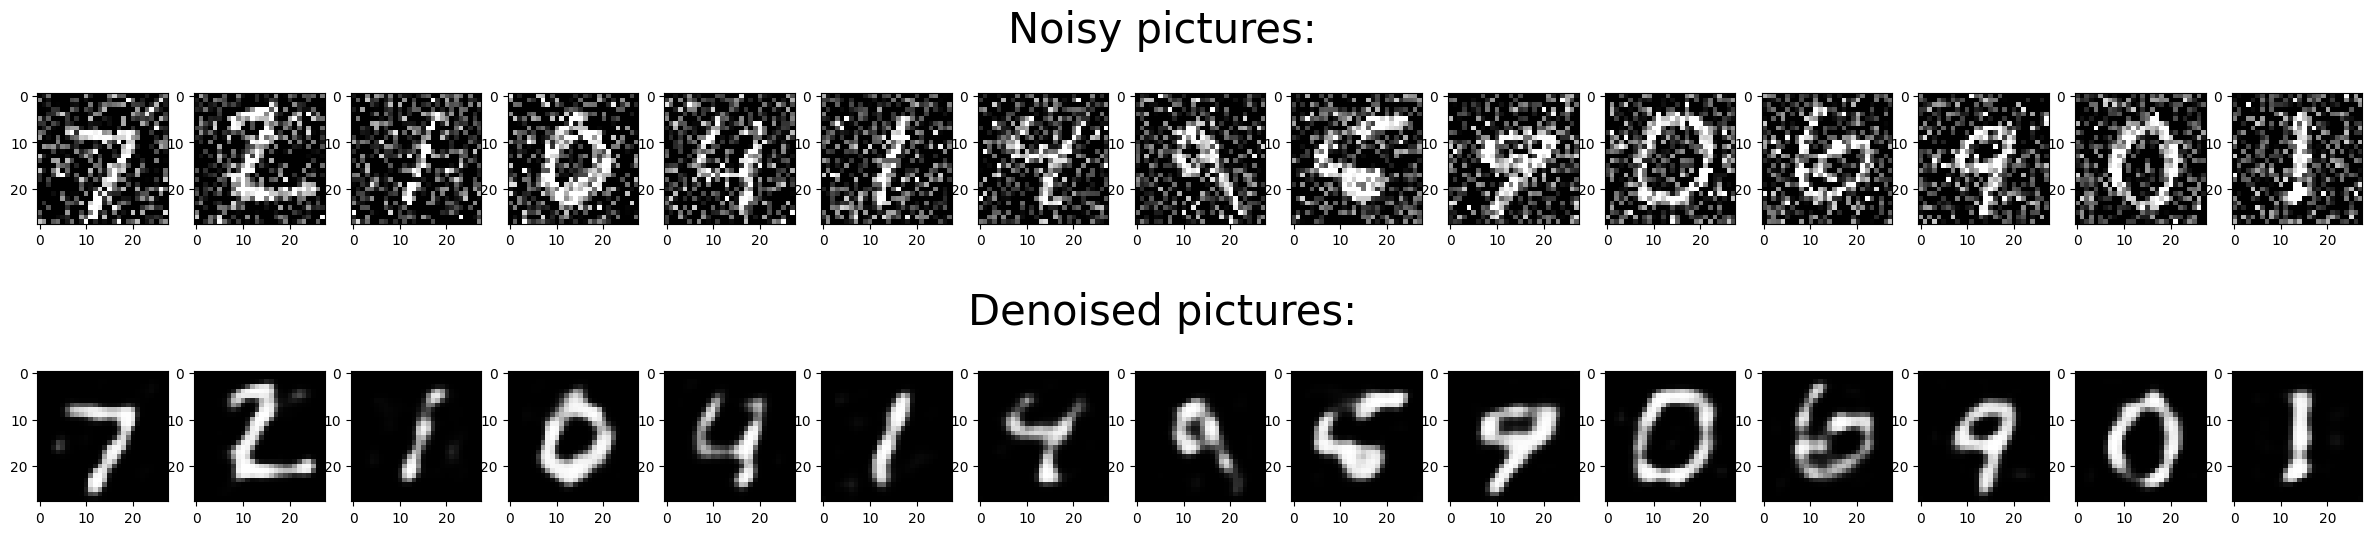

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=15, figsize=(30, 6))

# Plot the images
for images, row in zip([X_test_noisy[:15], denoised_images], axes):
    for img, ax in zip(images, row):
        ax.imshow(img.reshape((28, 28)), cmap='gray')

# Add labels above each row
fig.text(0.5, 0.92, 'Noisy pictures:', ha='center', fontsize=30)
fig.text(0.5, 0.45, 'Denoised pictures:', ha='center', fontsize=30)

# Adjust the space between rows
plt.subplots_adjust(hspace=0.5)  # Increase the space between rows
plt.show()